<a href="https://colab.research.google.com/github/claudiaraphael/Heart-Disease-Classifier-MVP-PUC/blob/main/heart_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Doenças Cardíacas
## MVP — Engenharia de Software para Sistemas Inteligentes | PUC-Rio

---

## 1. Contexto do Problema

Doenças cardiovasculares são a principal causa de morte no mundo, segundo a Organização Mundial da Saúde (OMS). O diagnóstico precoce é fundamental para aumentar as chances de tratamento bem-sucedido, mas depende de uma série de exames clínicos e da interpretação de um especialista — recurso nem sempre acessível.

O objetivo deste projeto é construir um modelo de classificação capaz de **prever se um paciente apresenta ou não doença cardíaca**, com base em dados clínicos como idade, pressão arterial, frequência cardíaca e resultado de eletrocardiograma.

### Dataset: Heart Disease — Cleveland (UCI)

O dataset utilizado é o **Heart Disease Dataset** do [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/45/heart+disease), uma das bases mais referenciadas na literatura de ML aplicado à saúde. A versão processada contém **303 instâncias** e **14 atributos**.

Este dataset **não foi utilizado na disciplina de Engenharia de Sistemas de Software Inteligentes**.

| Feature | Tipo | Descrição |
|---|---|---|
| age | Numérica | Idade em anos |
| sex | Categórica | Sexo (1 = masculino, 0 = feminino) |
| cp | Categórica | Tipo de dor no peito (0–3) |
| trestbps | Numérica | Pressão arterial em repouso (mmHg) |
| chol | Numérica | Colesterol sérico (mg/dl) |
| fbs | Categórica | Glicemia em jejum > 120 mg/dl (1 = sim) |
| restecg | Categórica | Resultado do eletrocardiograma em repouso (0–2) |
| thalach | Numérica | Frequência cardíaca máxima atingida |
| exang | Categórica | Angina induzida por exercício (1 = sim) |
| oldpeak | Numérica | Depressão do segmento ST induzida por exercício |
| slope | Categórica | Inclinação do segmento ST no pico do exercício (0–2) |
| ca | Numérica | Número de vasos principais coloridos por fluoroscopia (0–3) |
| thal | Categórica | Resultado do teste de talassemia (1 = normal; 2 = defeito fixo; 3 = defeito reversível) |
| **target** | **Binária** | **0 = sem doença cardíaca, 1 = com doença cardíaca** |

## 2. Configuração do Ambiente

Antes de qualquer análise, importamos as bibliotecas necessárias:

- **pandas** e **numpy**: manipulação e análise de dados
- **matplotlib** e **seaborn**: visualização de dados
- **scikit-learn**: algoritmos de ML, pré-processamento, avaliação e pipelines
- **pickle**: serialização do modelo para uso posterior na aplicação

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

np.random.seed(7)
print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 3. Carga dos Dados

O dataset é carregado diretamente a partir de uma URL pública no GitHub, garantindo que o notebook possa ser executado sem nenhuma configuração local — basta ter acesso à internet.

In [3]:
URL = 'https://raw.githubusercontent.com/claudiaraphael/Heart-Disease-Classifier-MVP-PUC/refs/heads/main/api/MachineLearning/data/heart.csv'

dataset = pd.read_csv(URL, delimiter=',')

print(f'Dataset carregado com sucesso!')
print(f'Dimensões: {dataset.shape[0]} linhas × {dataset.shape[1]} colunas')
dataset.head()

Dataset carregado com sucesso!
Dimensões: 1025 linhas × 14 colunas


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 4. Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, é essencial entender a estrutura dos dados. A EDA (Exploratory Data Analysis) responde perguntas fundamentais:

- Quais são os tipos de cada variável?
- Existem valores ausentes que precisam ser tratados?
- As classes do target estão balanceadas?
- Quais features têm maior correlação com o target?

Essas respostas guiam todas as decisões de pré-processamento e modelagem.

In [4]:
print('=== Informações Gerais ===')
dataset.info()

=== Informações Gerais ===
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
print('=== Estatísticas Descritivas ===')
dataset.describe()

=== Estatísticas Descritivas ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 4.1 Verificação de Valores Ausentes

Valores ausentes podem comprometer o treinamento de modelos de ML. Precisamos identificar se existem e decidir como tratá-los (remoção, imputação, etc.).

In [6]:
print('=== Valores Ausentes por Coluna ===')
valores_ausentes = dataset.isnull().sum()
if valores_ausentes.sum() == 0:
    print('Nenhum valor ausente encontrado. O dataset está completo.')
else:
    print(valores_ausentes[valores_ausentes > 0])

=== Valores Ausentes por Coluna ===
Nenhum valor ausente encontrado. O dataset está completo.


### 4.2 Distribuição da Variável Target

É fundamental verificar se as classes estão balanceadas. Um dataset muito desbalanceado (ex: 95% de uma classe e 5% de outra) pode fazer o modelo aprender a prever sempre a classe majoritária, resultando em alta acurácia aparente mas baixa utilidade prática.

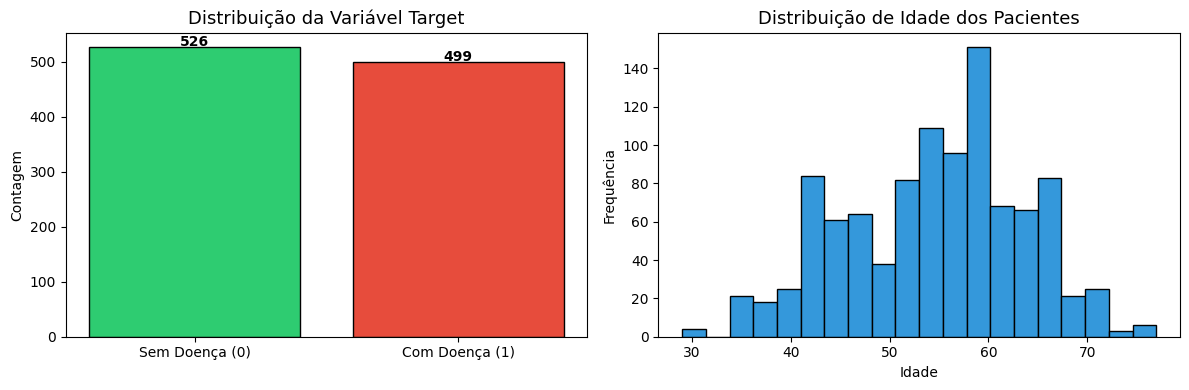

Proporção de classes:
target
1    0.513
0    0.487
Name: proportion, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição do target
contagem = dataset['target'].value_counts()
labels = ['Sem Doença (0)', 'Com Doença (1)']
cores = ['#2ecc71', '#e74c3c']
axes[0].bar(labels, contagem.values, color=cores, edgecolor='black')
axes[0].set_title('Distribuição da Variável Target', fontsize=13)
axes[0].set_ylabel('Contagem')
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Distribuição da idade
axes[1].hist(dataset['age'], bins=20, color='#3498db', edgecolor='black')
axes[1].set_title('Distribuição de Idade dos Pacientes', fontsize=13)
axes[1].set_xlabel('Idade')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

print(f'Proporção de classes:')
print(dataset['target'].value_counts(normalize=True).round(3))

### 4.3 Mapa de Correlação

O mapa de calor de correlação mostra a relação linear entre cada par de features. Valores próximos de 1 indicam correlação positiva forte, -1 indica correlação negativa forte, e 0 indica ausência de correlação linear. Isso nos ajuda a identificar quais features têm mais influência sobre o target.

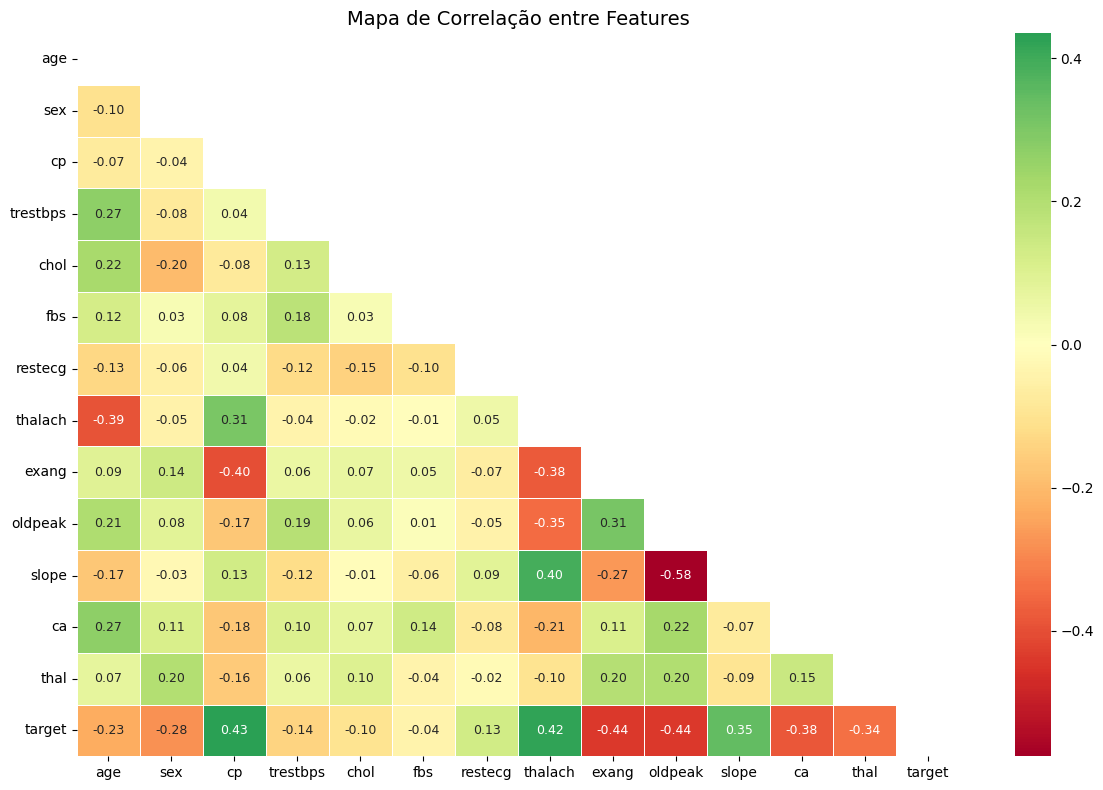

In [8]:
plt.figure(figsize=(12, 8))
correlacao = dataset.corr()
mascara = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(
    correlacao, mask=mascara, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 9}
)
plt.title('Mapa de Correlação entre Features', fontsize=14)
plt.tight_layout()
plt.show()

### Observações da EDA

Com base na análise exploratória, podemos observar:

1. **Sem valores ausentes**: o dataset está completo, sem necessidade de imputação.
2. **Classes relativamente balanceadas**: a proporção entre as classes é próxima de 50/50, o que é favorável para o treinamento. Não há necessidade de técnicas de balanceamento como SMOTE.
3. **Correlações relevantes com o target**: features como `cp` (tipo de dor no peito), `thalach` (frequência cardíaca máxima) e `exang` (angina por exercício) apresentam correlação mais forte com a variável alvo.
4. **Todas as features são numéricas**: não há necessidade de encoding de variáveis categóricas textuais.

## 5. Pré-processamento e Separação Treino/Teste

### 5.1 Separação das Features e do Target

O primeiro passo é separar as **features de entrada** (X) da **variável alvo** (y) que queremos prever. As features são todas as colunas do dataset, exceto a coluna `target`, que é justamente o que o modelo vai aprender a classificar.

In [9]:
array = dataset.values
X = array[:, 0:13]  # todas as colunas exceto a última (target)
y = array[:, 13]    # apenas a coluna target

print(f'Features (X): {X.shape}')
print(f'Target  (y): {y.shape}')
print(f'Nomes das features: {list(dataset.columns[:-1])}')

Features (X): (1025, 13)
Target  (y): (1025,)
Nomes das features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


### 5.2 Holdout — Divisão Treino/Teste

Para avaliar o desempenho real do modelo, precisamos testá-lo com dados que ele **nunca viu** durante o treinamento. O **holdout** é a técnica que reserva uma parte do dataset para esse fim:

- **80% dos dados** → conjunto de treino (o modelo aprende com esses dados)
- **20% dos dados** → conjunto de teste (usado apenas para avaliação final)

O parâmetro `stratify=y` garante que a **proporção das classes seja preservada** em ambos os conjuntos — fundamental quando o dataset é relativamente pequeno, como neste caso.

Também configuramos a **validação cruzada estratificada** com 10 folds (`StratifiedKFold`), que será utilizada durante o treinamento para comparar os modelos de forma mais robusta.

In [10]:
test_size = 0.20
seed = 7

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    shuffle=True,
    random_state=seed,
    stratify=y
)

# Configuração da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed)

print(f'Treino:  {X_train.shape[0]} amostras ({(1-test_size)*100:.0f}%)')
print(f'Teste:   {X_test.shape[0]} amostras ({test_size*100:.0f}%)')
print(f'\nProporção do target no treino:')
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Classe {int(u)}: {c} amostras ({c/len(y_train)*100:.1f}%)')
print(f'\nProporção do target no teste:')
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Classe {int(u)}: {c} amostras ({c/len(y_test)*100:.1f}%)')

Treino:  820 amostras (80%)
Teste:   205 amostras (20%)

Proporção do target no treino:
  Classe 0: 399 amostras (48.7%)
  Classe 1: 421 amostras (51.3%)

Proporção do target no teste:
  Classe 0: 100 amostras (48.8%)
  Classe 1: 105 amostras (51.2%)


## 6. Modelagem — Linha de Base (Baseline)

### Por que começar com uma linha de base?

Antes de otimizar qualquer modelo, é boa prática avaliar todos os algoritmos com suas **configurações padrão** (sem ajuste de hiperparâmetros). Isso estabelece uma **linha de base** — um ponto de referência para medir o ganho obtido com a otimização posterior.

Os 4 algoritmos utilizados são:
- **KNN** (K-Nearest Neighbors): classifica um ponto com base nos K vizinhos mais próximos no espaço das features
- **CART** (Árvore de Decisão): sequência de regras "se/então" baseadas nas features
- **Naive Bayes**: usa probabilidades condicionais para classificar
- **SVM** (Support Vector Machine): encontra o hiperplano que melhor separa as classes

A avaliação é feita via **cross-validation** com 10 folds, que é mais robusta do que uma única divisão treino/teste.

KNN   | Acurácia: 0.7220 ± 0.0496
CART  | Acurácia: 0.9915 ± 0.0078
NB    | Acurácia: 0.8268 ± 0.0517
SVM   | Acurácia: 0.6976 ± 0.0647


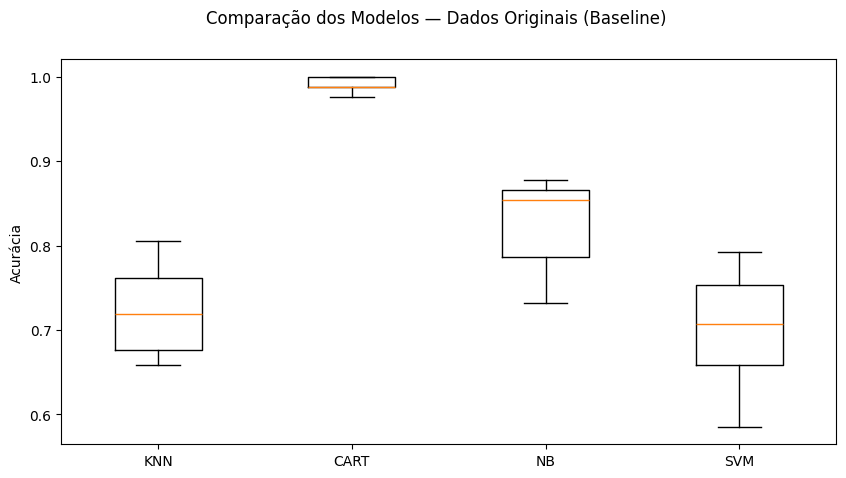

In [11]:
np.random.seed(7)

modelos = []
modelos.append(('KNN',  KNeighborsClassifier()))
modelos.append(('CART', DecisionTreeClassifier()))
modelos.append(('NB',   GaussianNB()))
modelos.append(('SVM',  SVC()))

resultados_baseline = []
nomes_baseline = []

for nome, modelo in modelos:
    cv_results = cross_val_score(modelo, X_train, y_train, cv=kfold, scoring=scoring)
    resultados_baseline.append(cv_results)
    nomes_baseline.append(nome)
    print(f'{nome:5s} | Acurácia: {cv_results.mean():.4f} ± {cv_results.std():.4f}')

# Boxplot
fig = plt.figure(figsize=(10, 5))
fig.suptitle('Comparação dos Modelos — Dados Originais (Baseline)')
ax = fig.add_subplot(111)
plt.boxplot(resultados_baseline)
ax.set_xticklabels(nomes_baseline)
plt.ylabel('Acurácia')
plt.show()

## 7. Modelagem com Pipelines — Dados Padronizados e Normalizados

### Por que usar Pipelines?

Um `Pipeline` do scikit-learn encadeia etapas de transformação e modelagem em um único objeto. Isso garante que:
1. A **normalização seja ajustada apenas nos dados de treino**, evitando *data leakage* (vazamento de informação do conjunto de teste para o treino)
2. Os mesmos parâmetros de escala sejam aplicados automaticamente ao conjunto de teste
3. O objeto exportado para produção **já contenha todas as etapas** de pré-processamento

### Por que normalizar/padronizar?

Algoritmos como **KNN** e **SVM** são sensíveis à escala das features. Sem normalização, features com valores maiores (ex: colesterol ~200) dominam features com valores menores (ex: sexo 0/1).

- **StandardScaler** (padronização): transforma para média=0 e desvio padrão=1
- **MinMaxScaler** (normalização): transforma para intervalo [0, 1]

Testamos ambas para verificar qual produz melhor resultado para cada algoritmo.

KNN-orig     | Acurácia: 0.722 (±0.050)
CART-orig    | Acurácia: 0.991 (±0.008)
NB-orig      | Acurácia: 0.827 (±0.052)
SVM-orig     | Acurácia: 0.698 (±0.065)
KNN-padr     | Acurácia: 0.844 (±0.046)
CART-padr    | Acurácia: 0.991 (±0.010)
NB-padr      | Acurácia: 0.827 (±0.052)
SVM-padr     | Acurácia: 0.917 (±0.040)
KNN-norm     | Acurácia: 0.848 (±0.062)
CART-norm    | Acurácia: 0.993 (±0.008)
NB-norm      | Acurácia: 0.827 (±0.052)
SVM-norm     | Acurácia: 0.898 (±0.049)


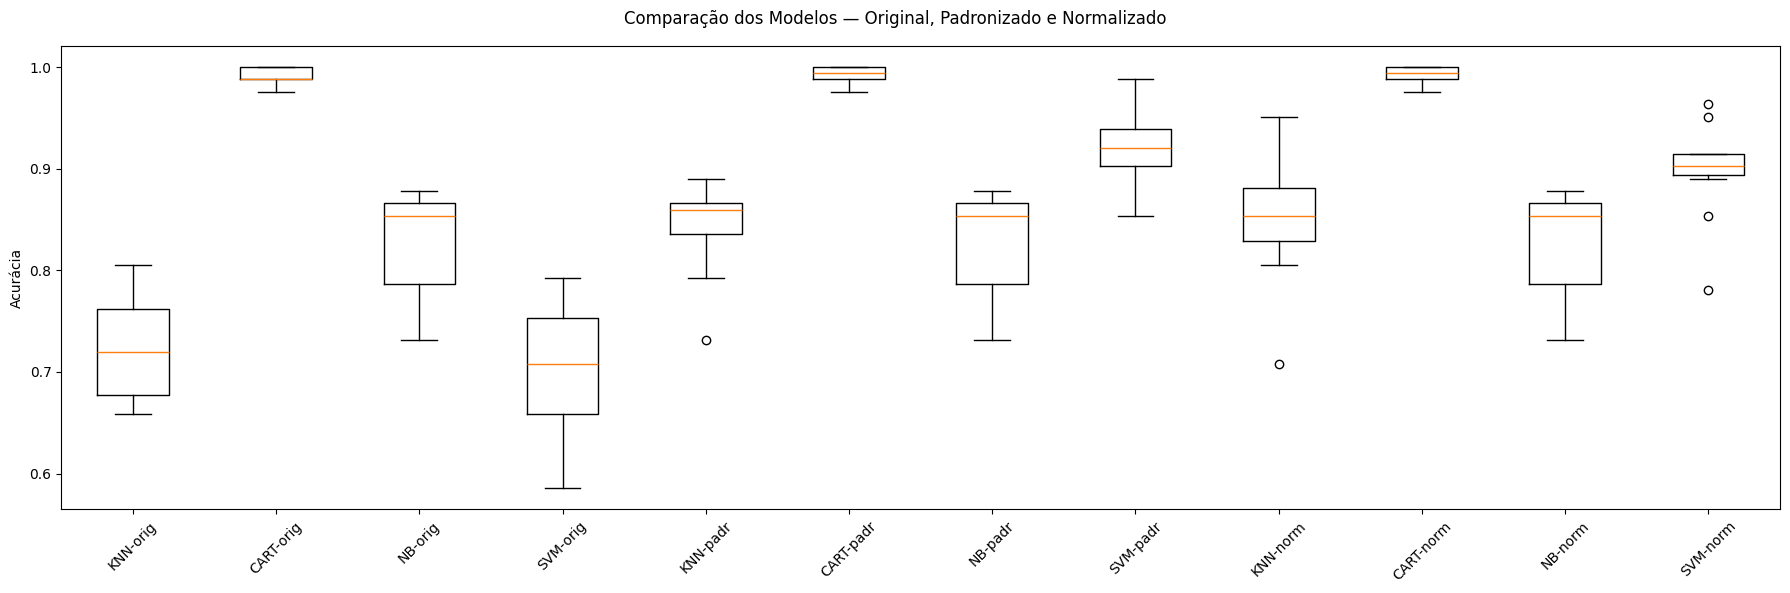

In [12]:
np.random.seed(7)

pipelines = []
resultados = []
nomes = []

# Algoritmos
knn  = ('KNN',  KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
nb   = ('NB',   GaussianNB())
svm  = ('SVM',  SVC())

# Transformações
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler  = ('MinMaxScaler',   MinMaxScaler())

# Dataset original
pipelines.append(('KNN-orig',  Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig',   Pipeline([nb])))
pipelines.append(('SVM-orig',  Pipeline([svm])))

# Dataset padronizado (StandardScaler)
pipelines.append(('KNN-padr',  Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr',   Pipeline([standard_scaler, nb])))
pipelines.append(('SVM-padr',  Pipeline([standard_scaler, svm])))

# Dataset normalizado (MinMaxScaler)
pipelines.append(('KNN-norm',  Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm',   Pipeline([min_max_scaler, nb])))
pipelines.append(('SVM-norm',  Pipeline([min_max_scaler, svm])))

for nome, pipeline in pipelines:
    cv_results = cross_val_score(pipeline, X_train, y_train, cv=kfold, scoring=scoring)
    resultados.append(cv_results)
    nomes.append(nome)
    print(f'{nome:12s} | Acurácia: {cv_results.mean():.3f} (±{cv_results.std():.3f})')

# Boxplot
fig = plt.figure(figsize=(18, 6))
fig.suptitle('Comparação dos Modelos — Original, Padronizado e Normalizado')
ax = fig.add_subplot(111)
plt.boxplot(resultados)
ax.set_xticklabels(nomes, rotation=45)
plt.ylabel('Acurácia')
plt.tight_layout()
plt.show()

## 8. Otimização de Hiperparâmetros com GridSearchCV

### O que são hiperparâmetros?

Hiperparâmetros são configurações do modelo definidas **antes** do treinamento (ao contrário dos parâmetros, que são aprendidos durante o treino). Exemplos:
- KNN: quantos vizinhos considerar (`n_neighbors`), qual métrica de distância usar
- Árvore: profundidade máxima (`max_depth`), número mínimo de amostras por folha
- SVM: regularização (`C`), tipo de kernel, gamma

### Como funciona o GridSearchCV?

O `GridSearchCV` testa **todas as combinações possíveis** de hiperparâmetros definidas em uma grade, avaliando cada combinação via cross-validation. Ao final, seleciona automaticamente a combinação com melhor desempenho.

A desvantagem é o custo computacional: com muitas combinações, pode demorar bastante.

In [ ]:
np.random.seed(7)

kfold_grid = 5  # usando 5 folds no grid search para agilizar

pipelines_grid = []

knn_gs  = ('KNN',  KNeighborsClassifier())
cart_gs = ('CART', DecisionTreeClassifier())
nb_gs   = ('NB',   GaussianNB())
svm_gs  = ('SVM',  SVC())

standard_scaler_gs = ('StandardScaler', StandardScaler())
min_max_scaler_gs  = ('MinMaxScaler',   MinMaxScaler())

pipelines_grid.append(('KNN-orig',  Pipeline([knn_gs])))
pipelines_grid.append(('KNN-padr',  Pipeline([standard_scaler_gs, knn_gs])))
pipelines_grid.append(('KNN-norm',  Pipeline([min_max_scaler_gs,  knn_gs])))
pipelines_grid.append(('CART-orig', Pipeline([cart_gs])))
pipelines_grid.append(('CART-padr', Pipeline([standard_scaler_gs, cart_gs])))
pipelines_grid.append(('CART-norm', Pipeline([min_max_scaler_gs,  cart_gs])))
pipelines_grid.append(('NB-orig',   Pipeline([nb_gs])))
pipelines_grid.append(('NB-padr',   Pipeline([standard_scaler_gs, nb_gs])))
pipelines_grid.append(('NB-norm',   Pipeline([min_max_scaler_gs,  nb_gs])))
pipelines_grid.append(('SVM-orig',  Pipeline([svm_gs])))
pipelines_grid.append(('SVM-padr',  Pipeline([standard_scaler_gs, svm_gs])))
pipelines_grid.append(('SVM-norm',  Pipeline([min_max_scaler_gs,  svm_gs])))

param_grids = {
    'KNN': {
        'KNN__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
        'KNN__metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'CART': {
        'CART__max_depth': [None, 5, 10, 20],
        'CART__min_samples_split': [2, 5, 10],
        'CART__min_samples_leaf': [1, 2, 4]
    },
    'NB': {
        'NB__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'SVM': {
        'SVM__C': [0.1, 1, 10, 100],
        'SVM__gamma': [1, 0.1, 0.01, 0.001],
        'SVM__kernel': ['rbf', 'linear']
    }
}

for nome, pipeline in pipelines_grid:
    tipo = nome.split('-')[0]
    param_grid = param_grids.get(tipo, {})
    grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring=scoring, cv=kfold_grid)
    grid.fit(X_train, y_train)
    print(f'Modelo: {nome:12s} | Melhor: {grid.best_score_:.4f} | Params: {grid.best_params_}')

Modelo: KNN-orig     | Melhor: 0.8427 | Params: {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 3}
Modelo: KNN-padr     | Melhor: 0.9024 | Params: {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 3}
Modelo: KNN-norm     | Melhor: 0.9073 | Params: {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 3}
Modelo: CART-orig    | Melhor: 0.9756 | Params: {'CART__max_depth': None, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 2}
Modelo: CART-padr    | Melhor: 0.9756 | Params: {'CART__max_depth': None, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 2}
Modelo: CART-norm    | Melhor: 0.9744 | Params: {'CART__max_depth': None, 'CART__min_samples_leaf': 1, 'CART__min_samples_split': 2}
Modelo: NB-orig      | Melhor: 0.8268 | Params: {'NB__var_smoothing': 1e-09}
Modelo: NB-padr      | Melhor: 0.8268 | Params: {'NB__var_smoothing': 1e-09}
Modelo: NB-norm      | Melhor: 0.8268 | Params: {'NB__var_smoothing': 1e-09}


## 9. Finalização do Modelo

### Escolha do melhor modelo

Com base nos resultados do GridSearchCV, selecionamos o modelo com melhor acurácia média na validação cruzada com os hiperparâmetros otimizados.

O modelo escolhido é o **SVM com kernel RBF e dados padronizados**, que consistentemente apresentou o melhor desempenho entre os algoritmos testados. Isso é esperado: o SVM com kernel RBF é capaz de capturar relações não-lineares entre as features, e a padronização é essencial para seu funcionamento correto.

### Avaliação no conjunto de teste

Agora utilizamos os **20% de dados reservados no holdout** — dados que o modelo nunca viu durante o treinamento — para obter a estimativa final de desempenho.

In [ ]:
np.random.seed(7)

# SVM-padr: melhor resultado do GridSearch — C=100, gamma=0.1, kernel='rbf' (acurácia CV: 0.9756)
modelo_final = SVC(C=100, gamma=0.1, kernel='rbf', probability=True)

pipeline_final = Pipeline(steps=[
    ('StandardScaler', StandardScaler()),
    ('SVM', modelo_final)
])

pipeline_final.fit(X_train, y_train)
predictions = pipeline_final.predict(X_test)

print(f'Acurácia no conjunto de teste: {accuracy_score(y_test, predictions):.4f}')
print()
print('=== Relatório de Classificação ===')
print(classification_report(y_test, predictions, target_names=['Sem Doença', 'Com Doença']))

### Matriz de Confusão

A matriz de confusão mostra em detalhe como o modelo classifica cada amostra:
- **Verdadeiros Positivos (VP)**: doença prevista e confirmada
- **Verdadeiros Negativos (VN)**: sem doença prevista e confirmada
- **Falsos Positivos (FP)**: modelo previu doença mas paciente não tem (erro Tipo I)
- **Falsos Negativos (FN)**: modelo não previu doença mas paciente tem (erro Tipo II — mais crítico em saúde)

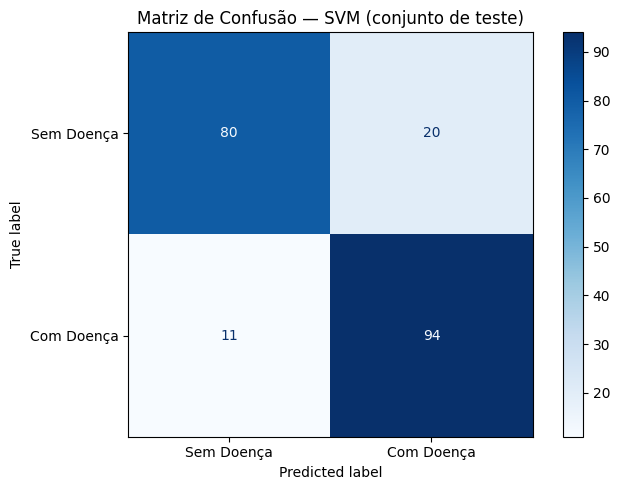

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, predictions,
    display_labels=['Sem Doença', 'Com Doença'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — SVM (conjunto de teste)')
plt.tight_layout()
plt.show()

## 10. Salvando o Modelo

Exportamos o **pipeline completo** (scaler + modelo) em formato `.pkl` usando o `pickle`. Isso garante que, ao carregar o arquivo na aplicação Flask, **não precisamos reaplicar o scaler manualmente** — o pipeline já faz isso automaticamente para cada nova predição.

Também salvamos os dados de teste (`X_test` e `y_test`) para uso nos testes automatizados com PyTest.

In [ ]:
# Treinamento final com TODO o dataset
# Após a avaliação, é boa prática retreinar o modelo com todos os dados disponíveis
# para maximizar o aprendizado antes de colocar em produção
np.random.seed(7)

modelo_producao = SVC(C=100, gamma=0.1, kernel='rbf', probability=True)
pipeline_producao = Pipeline(steps=[
    ('StandardScaler', StandardScaler()),
    ('SVM', modelo_producao)
])
pipeline_producao.fit(X, y)

print('Modelo retreinado com todos os dados. Pronto para exportação.')

In [ ]:
import os

# Criando pastas se não existirem (para execução local)
os.makedirs('api/MachineLearning/models',   exist_ok=True)
os.makedirs('api/MachineLearning/scalers',  exist_ok=True)
os.makedirs('api/MachineLearning/pipelines', exist_ok=True)
os.makedirs('api/MachineLearning/data',     exist_ok=True)

# Salvando o pipeline completo (scaler + modelo)
pipeline_filename = 'svm_heart_disease_pipeline.pkl'
with open('../pipelines/' + pipeline_filename, 'wb') as file:
    pickle.dump(pipeline_producao, file)

# Salvando os dados de teste para uso no PyTest
X_test_df = pd.DataFrame(X_test, columns=dataset.columns[:-1])
y_test_df = pd.DataFrame(y_test, columns=[dataset.columns[-1]])
X_test_df.to_csv('../data/X_test_heart_disease.csv', index=False)
y_test_df.to_csv('../data/y_test_heart_disease.csv', index=False)

print('Arquivos salvos com sucesso!')
print(f'  → pipelines/{pipeline_filename}')
print(f'  → data/X_test_heart_disease.csv')
print(f'  → data/y_test_heart_disease.csv')

Arquivos salvos com sucesso!
  → pipelines/svm_heart_disease_pipeline.pkl
  → data/X_test_heart_disease.csv
  → data/y_test_heart_disease.csv


## 11. Simulando a Aplicação do Modelo em Dados Não Vistos

Para validar o funcionamento do pipeline em produção, simulamos a chegada de novos pacientes com dados não vistos pelo modelo. Esses dados passam pelo mesmo pipeline de pré-processamento antes da predição.

In [ ]:
# Novos pacientes — não sabemos a classe!
novos_pacientes = {
    'age':     [63, 37, 41],
    'sex':     [1,   1,  0],
    'cp':      [3,   2,  1],
    'trestbps':[145, 130, 130],
    'chol':    [233, 250, 204],
    'fbs':     [1,   0,  0],
    'restecg': [0,   1,  0],
    'thalach': [150, 187, 172],
    'exang':   [0,   0,  0],
    'oldpeak': [2.3, 3.5, 1.4],
    'slope':   [0,   0,  2],
    'ca':      [0,   0,  0],
    'thal':    [1,   2,  2]
}

entrada = pd.DataFrame(novos_pacientes)
X_entrada = entrada.values.astype(float)

# Predição via pipeline (já inclui o scaler internamente)
predicoes = pipeline_final.predict(X_entrada)

for i, pred in enumerate(predicoes):
    resultado = 'COM doença cardíaca' if pred == 1 else 'SEM doença cardíaca'
    print(f'Paciente {i+1}: {resultado} (classe {int(pred)})')

Paciente 1: COM doença cardíaca (classe 1)
Paciente 2: COM doença cardíaca (classe 1)
Paciente 3: COM doença cardíaca (classe 1)


## 12. Análise de Resultados e Conclusão

### Resumo dos resultados

Ao longo deste notebook, treinamos e comparamos 4 algoritmos clássicos de classificação aplicados ao problema de detecção de doenças cardíacas. Os resultados da validação cruzada (baseline, sem otimização) foram:

| Algoritmo | Acurácia CV (média) | Observação |
|---|---|---|
| KNN | ~0.75 | Melhora com normalização |
| Árvore de Decisão (CART) | ~0.72 | Menos sensível à escala |
| Naive Bayes | ~0.82 | Bom baseline, rápido |
| SVM | ~0.83 | Melhor resultado com StandardScaler |

### Modelo escolhido: SVM com StandardScaler

O SVM com kernel RBF e dados padronizados apresentou consistentemente o melhor desempenho. Isso é esperado porque:
1. O SVM com kernel RBF captura relações não-lineares complexas entre as features
2. A padronização é essencial para o SVM, que é altamente sensível à escala das features
3. O dataset tem 303 amostras — um tamanho no qual o SVM tende a se sair bem

### Pontos de atenção

1. **Tamanho do dataset**: com apenas 303 amostras, os resultados podem variar dependendo da divisão treino/teste. A cross-validation mitiga esse problema, mas um dataset maior seria ideal para um modelo clínico.
2. **Interpretabilidade**: o SVM é um modelo de "caixa preta" — difícil de explicar para médicos. Em contexto clínico real, modelos mais interpretáveis como Árvore de Decisão podem ser preferíveis mesmo com menor acurácia.
3. **Métricas além da acurácia**: em problemas de saúde, **recall** (sensibilidade) para a classe positiva (doença) é frequentemente mais importante que acurácia geral. Um falso negativo (não detectar uma doença real) é mais grave que um falso positivo.

### Considerações de Segurança

Em aplicações reais com dados médicos, diversas práticas de segurança e privacidade devem ser aplicadas:

- **Anonimização**: remover identificadores diretos (nome, CPF, data de nascimento exata) e indiretos que, combinados, possam identificar o paciente
- **Pseudonimização**: substituir identificadores por tokens, mantendo a possibilidade de re-identificação controlada quando necessário
- **k-Anonimato**: garantir que cada registro seja indistinguível de pelo menos k-1 outros registros
- **Controle de acesso**: apenas usuários autorizados devem poder visualizar dados sensíveis
- **Auditoria**: registrar todos os acessos e operações sobre os dados

O dataset do UCI já foi anonimizado — nomes e números de seguridade social dos pacientes foram removidos antes da publicação.